# Deep Learning

### *Nina Haide*

## Introduction

This notebook represents the deep learning component of the portfolio, building directly on the previous clustering project for DACH AI job postings by keyword-extracted skill profiles. It asks the same question at a deeper level of representation: Can we discover meaningful AI job market personas from the semantic content of job descriptions using a Transformer-based model?

Rather than matching predefined keywords, this project encodes full job description text using DistilBERT, a pre-trained Transformer model and applies clustering to the resulting dense semantic vectors. The experimental comparison tests whether Transformer embeddings produce more coherent and meaningful role archetypes than a classical TF-IDF baseline - directly demonstrating the value of deep learning representations over traditional text vectorisation. The geographic scope is expanded beyond DACH to include the United Kingdom, France and the Netherlands,providing a broader European perspective on AI role archetypes.

### Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [2]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 3.7 MB/s  0:00:21 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.9 MB/s  0:00:00m 3.9 MB/s eta 0:00:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.0
    Uninstalling setuptools-82.0.0:
      Successfully uninstalled setuptools-82.0.0━━━━━━ 0/2 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torch]━━━━━ 1/2 [torch]


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Data Set

The dataset was created using a custom collection pipeline built on the Adzuna
Jobs API, extended from the DACH-focused scripts developed previous projects.
The collection script `fetch_ai_jobs_personas.py` queries AI job postings
across six countries - Germany, United Kingdom, France, Netherlands, Austria and
Switzerland - using 30 targeted search queries spanning five role categories:
AI Engineering, Data Analytics, AI Product and Project Management, AI Integration
and AI Consulting. English-language queries run across all countries; German-language
queries are restricted to DACH.

Because the Adzuna API truncates descriptions at approximately 500 characters,
a secondary enrichment step (`enrich_descriptions.py`) follows each posting's
redirect URL, fetches the full job page from the source website and replaces the
truncated text with the complete description. The final dataset is stored in
`adzuna_ai_jobs_europe_enriched.csv`. After filtering out postings where enrichment
failed, the modeling dataset contains job postings with full descriptions used as
input to the DistilBERT encoder. The United Kingdom and Germany account for the
majority of entries (675 and 409 respectively), with France, Netherlands, Austria
and Switzerland contributing the remainder.

In [5]:
df = pd.read_csv("adzuna_ai_jobs_europe.csv")
df.head()

,id,title,company,location,country,country_code,category,contract_type,contract_time,salary_min,salary_max,date_posted,description,role_category,search_query,url,desc_length
0,de_5708353171,Senior Engineer Machine Learning / AI (w/m/d),HUK-COBURG Versicherungsgruppe,"Coburg, Coburg (Kreis)",Germany,de,Technikerstellen,NaN,NaN,NaN,NaN,2026-04-23,"Hallo, lass uns WIR sagen! Wir - die HUK-COBUR...",AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/land/ad/5708353171?se=Io...,500
1,de_5722278756,AI & Machine Learning Engineer (all genders),SThree Germany,"Hausen, Frankfurt am Main",Germany,de,IT-Stellen,permanent,full_time,80000.0,95000.0,2026-05-08,AI & Machine Learning Engineer (all genders) U...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5722278756?utm_m...,500
2,de_5680334179,Digital Process Engineer – AI & Automation (KI...,GPE MedTech Systeme GmbH,"Dassow, Nordwestmecklenburg (Kreis)",Germany,de,Beraterstellen,NaN,NaN,NaN,NaN,2026-03-27,Digital Process Engineer – AI & Automation (KI...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5680334179?utm_m...,500
3,de_5418313407,Senior AI / Machine Learning Engineer – Enterp...,Nortal,Deutschland,Germany,de,IT-Stellen,permanent,full_time,NaN,NaN,2025-09-27,Wir bei Nortal unterstützen den öffentlichen S...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5418313407?utm_m...,500
4,de_5698582069,AI & Machine Learning Engineer – Sensor Fusion...,Collective.work,"Altstadt-Lehel, München",Germany,de,Sonstige/Allgemeine Stellen,permanent,full_time,65000.0,105000.0,2026-04-14,Job description Salary: 65-105k€ (Annuel) AI &...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5698582069?utm_m...,500


In [6]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (1328, 17)

Columns: ['id', 'title', 'company', 'location', 'country', 'country_code', 'category', 'contract_type', 'contract_time', 'salary_min', 'salary_max', 'date_posted', 'description', 'role_category', 'search_query', 'url', 'desc_length']

Data types:
id                   str
title                str
company              str
location             str
country              str
country_code         str
category             str
contract_type        str
contract_time        str
salary_min       float64
salary_max       float64
date_posted          str
description          str
role_category        str
search_query         str
url                  str
desc_length        int64
dtype: object


In [7]:
print(f"Total job postings : {len(df)}")
print(f"Text input column  : description_full")
print(f"Label column       : role_category (used for evaluation, not training)")

print("\nRole category distribution:")
print(df["role_category"].value_counts())

print("\nCountry distribution:")
print(df["country"].value_counts())

Total job postings : 1328
Text input column  : description_full
Label column       : role_category (used for evaluation, not training)

Role category distribution:
role_category
AI_Engineering    369
AI_PM             348
Data_Analytics    231
AI_Consulting     200
AI_Integration    180
Name: count, dtype: int64

Country distribution:
country
United Kingdom    675
Germany           409
France            137
Switzerland        43
Netherlands        34
Austria            30
Name: count, dtype: int64


In [8]:
print("Missing values:")
print(df.isnull().sum())

print(f"\nDuplicate IDs: {df['id'].duplicated().sum()}")
print(f"\nEmpty descriptions: {(df['description'].str.strip() == '').sum()}")

# Flag postings too short for meaningful embedding
min_length = 200
short = df[df["desc_length"] < min_length]
print(f"\nPostings below {min_length} chars (insufficient for embedding): {len(short)}")

Missing values:
id                  0
title               0
company             1
location            0
country             0
country_code        0
category            0
contract_type    1087
contract_time     674
salary_min        600
salary_max        600
date_posted         0
description         0
role_category       0
search_query        0
url                 0
desc_length         0
dtype: int64

Duplicate IDs: 0

Empty descriptions: 0

Postings below 200 chars (insufficient for embedding): 0


The dataset contains 1,328 job postings collected via the Adzuna Jobs API across
six European countries. The primary data quality concern is description completeness:
the Adzuna API truncates descriptions at 500 characters.
High rates of missing values in contract_type, contract_time, salary_min and
salary_max are expected - Adzuna does not consistently return these fields for
European markets. These columns are not used in the modeling pipeline. The
role_category column is derived from the search query used to collect each posting
and serves as a metadata label for post-clustering evaluation rather than a
training target, since this is an unsupervised task.

In [9]:
df_enriched = pd.read_csv("adzuna_ai_jobs_europe_enriched.csv")
df_enriched.head()

,id,title,company,location,country,country_code,category,contract_type,contract_time,salary_min,salary_max,date_posted,description,role_category,search_query,url,desc_length,description_full,description_length
0,de_5708353171,Senior Engineer Machine Learning / AI (w/m/d),HUK-COBURG Versicherungsgruppe,"Coburg, Coburg (Kreis)",Germany,de,Technikerstellen,NaN,NaN,NaN,NaN,2026-04-23,"Hallo, lass uns WIR sagen! Wir - die HUK-COBUR...",AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/land/ad/5708353171?se=Io...,500,"Hallo, lass uns WIR sagen! Wir - die HUK-COBUR...",500
1,de_5722278756,AI & Machine Learning Engineer (all genders),SThree Germany,"Hausen, Frankfurt am Main",Germany,de,IT-Stellen,permanent,full_time,80000.0,95000.0,2026-05-08,AI & Machine Learning Engineer (all genders) U...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5722278756?utm_m...,500,AI & Machine Learning Engineer (all genders) ❮...,4042
2,de_5680334179,Digital Process Engineer – AI & Automation (KI...,GPE MedTech Systeme GmbH,"Dassow, Nordwestmecklenburg (Kreis)",Germany,de,Beraterstellen,NaN,NaN,NaN,NaN,2026-03-27,Digital Process Engineer – AI & Automation (KI...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5680334179?utm_m...,500,Digital Process Engineer – AI & Automation (KI...,5000
3,de_5418313407,Senior AI / Machine Learning Engineer – Enterp...,Nortal,Deutschland,Germany,de,IT-Stellen,permanent,full_time,NaN,NaN,2025-09-27,Wir bei Nortal unterstützen den öffentlichen S...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5418313407?utm_m...,500,Senior AI / Machine Learning Engineer – Enterp...,5000
4,de_5698582069,AI & Machine Learning Engineer – Sensor Fusion...,Collective.work,"Altstadt-Lehel, München",Germany,de,Sonstige/Allgemeine Stellen,permanent,full_time,65000.0,105000.0,2026-04-14,Job description Salary: 65-105k€ (Annuel) AI &...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5698582069?utm_m...,500,AI & Machine Learning Engineer – Sensor Fusion...,3763


In [10]:
print("Shape:", df_enriched.shape)
print("\nColumns:", df_enriched.columns.tolist())

Shape: (1328, 19)

Columns: ['id', 'title', 'company', 'location', 'country', 'country_code', 'category', 'contract_type', 'contract_time', 'salary_min', 'salary_max', 'date_posted', 'description', 'role_category', 'search_query', 'url', 'desc_length', 'description_full', 'description_length']


In [11]:
print("Description length stats:")
print(df_enriched["description_length"].describe())
print(f"\nFetch failed — still at 500 chars : {(df_enriched['description_length'] <= 500).sum()}")
print(f"Enriched — full descriptions      : {(df_enriched['description_length'] > 500).sum()}")

Description length stats:
count    1328.000000
mean     3998.582831
std      1718.090212
min       500.000000
25%      3908.250000
50%      5000.000000
75%      5000.000000
max      5000.000000
Name: description_length, dtype: float64

Fetch failed — still at 500 chars : 240
Enriched — full descriptions      : 1088


In [12]:
print("Role category distribution:")
print(df_enriched["role_category"].value_counts())

print("\nCountry distribution:")
print(df_enriched["country"].value_counts())

Role category distribution:
role_category
AI_Engineering    369
AI_PM             348
Data_Analytics    231
AI_Consulting     200
AI_Integration    180
Name: count, dtype: int64

Country distribution:
country
United Kingdom    675
Germany           409
France            137
Switzerland        43
Netherlands        34
Austria            30
Name: count, dtype: int64


In [13]:
print("Missing values:")
print(df_enriched.isnull().sum())
print(f"\nDuplicate IDs: {df_enriched['id'].duplicated().sum()}")

Missing values:
id                       0
title                    0
company                  1
location                 0
country                  0
country_code             0
category                 0
contract_type         1087
contract_time          674
salary_min             600
salary_max             600
date_posted              0
description              0
role_category            0
search_query             0
url                      0
desc_length              0
description_full         0
description_length       0
dtype: int64

Duplicate IDs: 0


The raw dataset contains 1,328 unique job postings with no duplicate IDs and no
empty descriptions. The enriched dataset recovers full descriptions for
1,088 of 1,328 postings (82%), with a mean description length of approximately
4,000 characters and a median at the 5,000-character cap. The 240 postings where
enrichment failed will be excluded from modeling. Non-critical fields including
contract_type, salary_min, and salary_max have high missing value rates reflecting
Adzuna's inconsistent coverage of these fields across European markets - these
columns are not used in the modeling pipeline.

## Baseline Deep Learning Model

The baseline model is a PyTorch Autoencoder trained on TF-IDF vectors of job
descriptions. An autoencoder learns to compress high-dimensional input into a
lower-dimensional latent representation and reconstruct it, forcing the network
to capture the most important structure in the data. The latent vectors are then
used as input to K-Means clustering - the same clustering step used in the
experimental model, isolating the effect of the text representation method.
This establishes a meaningful baseline: TF-IDF captures word frequency patterns
but has no semantic understanding. 

In [14]:
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [15]:
# Load enriched dataset and filter to postings with full descriptions
df = pd.read_csv("adzuna_ai_jobs_europe_enriched.csv")
df_model = df[df["description_length"] > 500].copy().reset_index(drop=True)
print(f"Modeling dataset: {len(df_model)} jobs")

# TF-IDF vectorisation
tfidf = TfidfVectorizer(max_features=500, stop_words="english", min_df=2)
X_tfidf = tfidf.fit_transform(df_model["description_full"]).toarray().astype(np.float32)
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

Modeling dataset: 1088 jobs
TF-IDF matrix shape: (1088, 500)


### Model Architecture

The autoencoder has a symmetric encoder-decoder structure:

- **Encoder:** 500 → 128 → 32 (latent space)
- **Decoder:** 32 → 128 → 500 (reconstruction)
- **Activation:** ReLU on hidden layers, Sigmoid on the output layer
  (TF-IDF values are in [0,1] so Sigmoid is appropriate for reconstruction)
- **Loss:** Mean Squared Error - measures reconstruction quality
- **Optimizer:** Adam (lr=0.001)

The 32-dimensional latent space is the output used for clustering.
A smaller latent space forces the model to learn a more compressed
and meaningful representation of each job description.

In [16]:
class JobAutoencoder(nn.Module):
    def __init__(self, input_dim=500, latent_dim=32):
        super(JobAutoencoder, self).__init__()

        # Encoder: compress input to latent representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        # Decoder: reconstruct input from latent representation
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()  # TF-IDF values are in [0, 1]
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

    def encode(self, x):
        return self.encoder(x)


model = JobAutoencoder(input_dim=500, latent_dim=32)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

JobAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=500, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=500, bias=True)
    (3): Sigmoid()
  )
)

Total parameters: 136,980


In [17]:
# DataLoader
X_tensor = torch.tensor(X_tfidf)
dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 50
train_losses = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for (batch,) in loader:
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} — Loss: {avg_loss:.6f}")

Epoch  10/50 — Loss: 0.001632
Epoch  20/50 — Loss: 0.001288
Epoch  30/50 — Loss: 0.001068
Epoch  40/50 — Loss: 0.000987
Epoch  50/50 — Loss: 0.000939


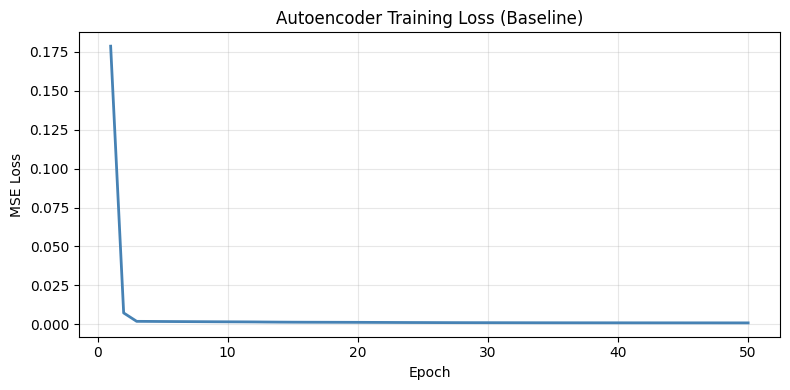

Final training loss: 0.000939


In [18]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, linewidth=2, color="steelblue")
plt.title("Autoencoder Training Loss (Baseline)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("viz_baseline_loss.png", dpi=150)
plt.show()
print(f"Final training loss: {train_losses[-1]:.6f}")

In [19]:
model.eval()
with torch.no_grad():
    X_latent = model.encode(X_tensor).numpy()

print(f"Latent space shape: {X_latent.shape}")

# K-Means on latent vectors
K = 5
km_baseline = KMeans(n_clusters=K, random_state=42, n_init=10)
baseline_labels = km_baseline.fit_predict(X_latent)

sil_baseline = silhouette_score(X_latent, baseline_labels)
print(f"Baseline silhouette score (k={K}): {sil_baseline:.4f}")

# Attach labels
df_model["cluster_baseline"] = baseline_labels
print("\nCluster sizes:")
print(df_model["cluster_baseline"].value_counts().sort_index())

Latent space shape: (1088, 32)
Baseline silhouette score (k=5): 0.4183

Cluster sizes:
cluster_baseline
0     79
1    131
2    476
3    167
4    235
Name: count, dtype: int64


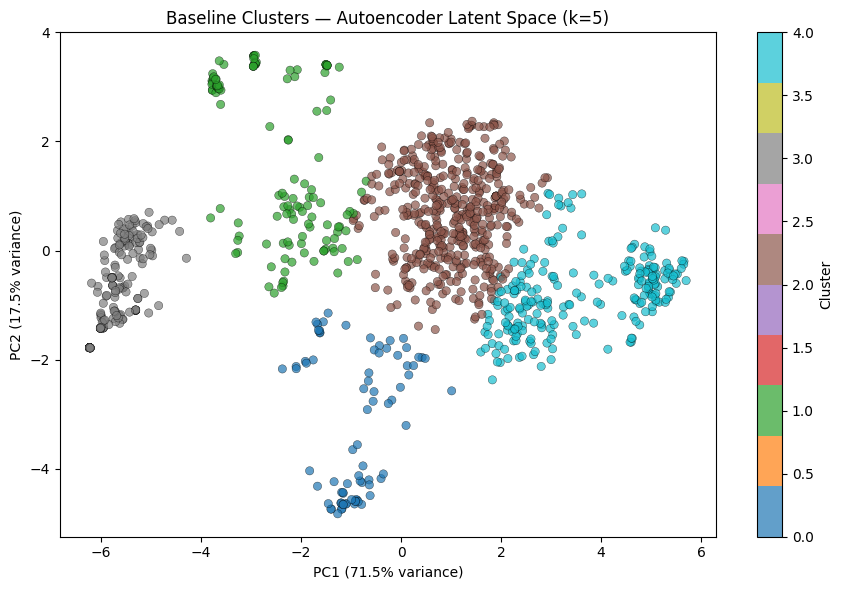

In [20]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_latent)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=baseline_labels, cmap="tab10",
                      alpha=0.7, edgecolors="k", linewidths=0.3)
plt.colorbar(scatter, label="Cluster")
plt.title(f"Baseline Clusters — Autoencoder Latent Space (k={K})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("viz_baseline_clusters.png", dpi=150)
plt.show()

In [ ]:
pip freeze > requirements.txt